# Fogler P12-8 Solution

## Why Are We Learning This?
This problem combines nearly every major topic from the second half of CBE 3610: mole balances, energy balances, change in volumetric flowrate of a gas, reversible reactions, equilibrium, Arrhenius kinetics, van't Hoff relationships, and numerical solution of coupled differential equations using solve_ivp.

## Learning Objectives
- Derive coupled mole and energy balances for a non-isothermal PFR
- Calculate temperature-dependent concentrations, rate constants, and equilibrium constants
- Calculate equilibrium conversion
- Solve coupled initial value problems using solve_ivp
- Compare actual conversion and equilibrium conversion
- Interpret reactor performance for different heat exchange scenarios

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Problem Statement Data

In [ ]:
FA0=5.0
CA0=2.0
T0=300.0
Vf=40.0
CPA=0.160
CPB=0.160
DCp = CPB-CPA
DHrxn=-20.0
E=10.0
k_ref=0.1
Kc_ref=1000.0
Tref=300.0
R=0.001987

## Step 1: Mole Balance
For a PFR:

$$\frac{dX}{dV}=\frac{-r_A}{F_{A0}}$$

## Step 2: Concentration Equations
For A $\leftrightharpoons$ B with pure A feed and no net change in moles ($\delta = 0$) being carried out in the gas phase in a non-isothermal flow reactor:

$$C_A=C_{A0}(1-X)\frac{T_0}{T}$$

$$C_B=C_{A0}X\frac{T_0}{T}$$

In [ ]:
def CA(X,T):
    return CA0*(1-X)*(T0/T)

def CB(X,T):
    return CA0*X*(T0/T)

## Step 3: Arrhenius Equation

In [ ]:
def kf(T):
    return k_ref*np.exp(E/R*(1/Tref-1/T))

## Step 4: van't Hoff Equation

In [ ]:
def Kc(T):
    return Kc_ref*np.exp((-DHrxn/R)*(1/T-1/Tref))

## Step 5: Rate Law


In [ ]:
def rate(X,T):
    return -kf(T)*(CA(X,T) - CB(X,T)/Kc(T))

## Step 6: Derive Equilibrium Conversion
Equilibrium constant:

$$ K_C = \frac{C_{B,e}}{C_{A,e}} $$

where

$$C_{A,e}=C_{A0}(1-X_e)\frac{T_0}{T}$$

$$C_{B,e}=C_{A0}X_e\frac{T_0}{T}$$

therefore:

$$ K_C = \frac{1-X_e}{X_e} $$

so

$$ X_e = \frac{K_C}{1+K_C} $$



In [ ]:
def Xe(T):
    K=Kc(T)
    return K/(1+K)

## Step 7: PFR Energy Balance

### Adiabatic

$$ T = T_0 + \frac{(-\Delta H^{rxn})X}{\sum_i \Theta_i C_{P,i}} $$

### With heat exchanger

$$\frac{dT}{dV} = \frac{r_A \Delta H^{rxn} + Ua(T_a-T)}{F_{A0}\left(\sum_i \Theta_i C_{P,i} + \Delta C_PX\right)} $$



## Step 8: Heat exchanger energy balance:

Needed if the cooling fluid temperature is not constant. In that case:

### Co-current

$$\frac{dT_a}{dV} = \frac{Ua(T-T_a)}{F_{cool}C_{P,cool}} $$

### Counter-current

$$\frac{dT_a}{dV} = -\frac{Ua(T-T_a)}{F_{cool}C_{P,cool}} $$

## Step 9: Solve the different scenarios

### Adiabatic

In [ ]:
def T_ad(X):
  return T0+(-DHrxn*X)/CPA

In [ ]:
def adiabatic(V,y):
    X=y
    T = T_ad(X)
    r=rate(X,T)
    dXdV=-r/FA0
    return [dXdV]

In [ ]:
x0=0
sol_ad=solve_ivp(adiabatic,[0,Vf],[x0],t_eval=np.linspace(0,Vf,500))
V=sol_ad.t
X_ad=sol_ad.y[0]
T_ad_plot=T_ad(X_ad)
Xe_ad=Xe(T_ad_plot)

#### Plot Conversion and Equilibrium Conversion

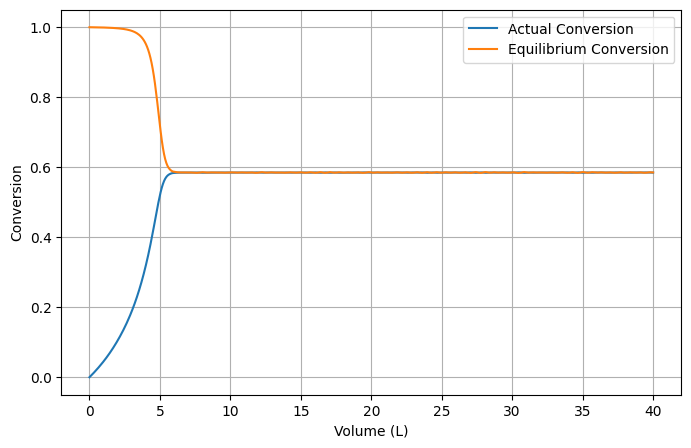

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,X_ad,label="Actual Conversion")
plt.plot(V,Xe_ad,label="Equilibrium Conversion")
plt.xlabel("Volume (L)")
plt.ylabel("Conversion")
plt.legend()
plt.grid()
plt.show()

#### Plot Temperature

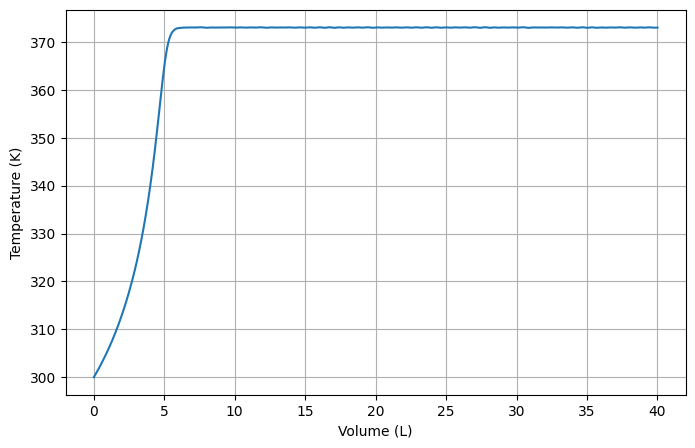

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,T_ad_plot)
plt.xlabel("Volume (L)")
plt.ylabel("Temperature (K)")
plt.grid()
plt.show()

#### Plot the Rate

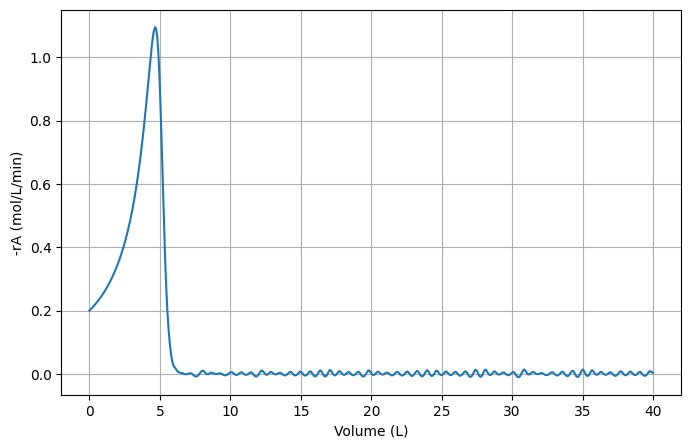

In [ ]:
r_profile_ad=-rate(X_ad,T_ad_plot)
plt.figure(figsize=(8,5))
plt.plot(V,r_profile_ad)
plt.xlabel("Volume (L)")
plt.ylabel("-rA (mol/L/min)")
plt.grid()
plt.show()

#### Reactor Exit Conditions

In [ ]:
print("Exit Conversion:",X_ad[-1])
print("Exit Temperature (K):",T_ad_plot[-1])
print("Exit Equilibrium Conversion:",Xe_ad[-1])
print("Fraction of Equilibrium Achieved:",X_ad[-1]/Xe_ad[-1])

Exit Conversion: 0.5840111706035902
Exit Temperature (K): 373.0013963254488
Exit Equilibrium Conversion: 0.58450409812269
Fraction of Equilibrium Achieved: 0.999156673972547


#### Maximum T

In [ ]:
print("Maximum Temperature (K):",np.max(T_ad_plot))

Maximum Temperature (K): 373.0760632417568


### Constant Ta

In [ ]:
Ua = 0.15
Ta = 300
def constTa(V,y):
    X,T=y
    r=rate(X,T)
    dXdV=-r/FA0
    dTdV=(r*DHrxn+Ua*(Ta-T))/(FA0*CPA)
    return [dXdV,dTdV]

In [ ]:
sol_constTa=solve_ivp(constTa,[0,Vf],[x0,T0],t_eval=np.linspace(0,Vf,500))
V=sol_constTa.t
X_constTa=sol_constTa.y[0]
T_constTa=sol_constTa.y[1]
Xe_constTa=Xe(T_constTa)


#### Plot Conversion and Equilibrium Conversion

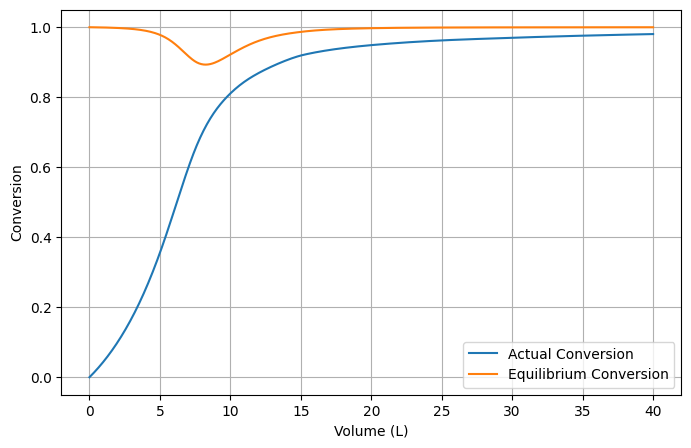

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,X_constTa,label="Actual Conversion")
plt.plot(V,Xe_constTa,label="Equilibrium Conversion")
plt.xlabel("Volume (L)")
plt.ylabel("Conversion")
plt.legend()
plt.grid()
plt.show()

#### Plot Temperature

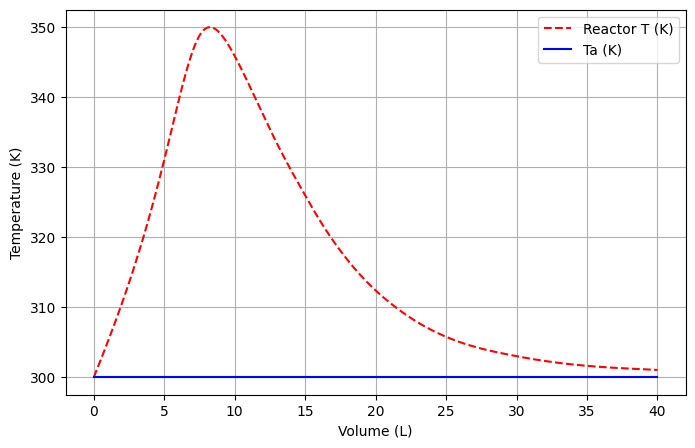

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,T_constTa,"r--",label="Reactor T (K)")
plt.plot(V,Ta*np.ones_like(T_constTa),"b-",label="Ta (K)")
plt.xlabel("Volume (L)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid()
plt.show()

#### Plot the Rate

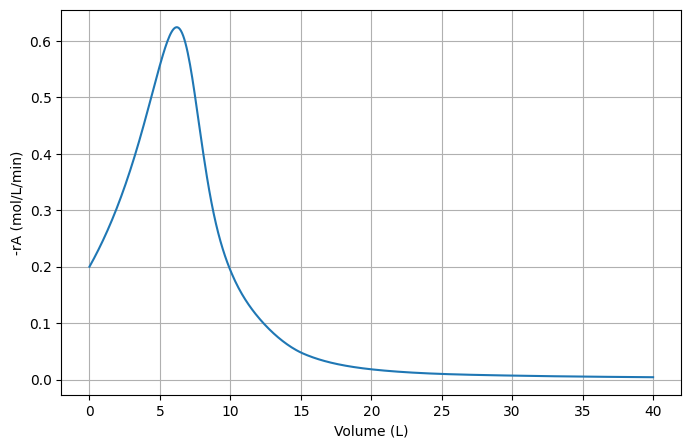

In [ ]:
r_profile_constTa=-rate(X_constTa,T_constTa)
plt.figure(figsize=(8,5))
plt.plot(V,r_profile_constTa)
plt.xlabel("Volume (L)")
plt.ylabel("-rA (mol/L/min)")
plt.grid()
plt.show()

#### Reactor Exit Conditions

In [ ]:
print("Exit Conversion:",X_constTa[-1])
print("Exit Temperature (K):",T_constTa[-1])
print("Exit Equilibrium Conversion:",Xe_constTa[-1])
print("Fraction of Equilibrium Achieved:",X_constTa[-1]/Xe_constTa[-1])

Exit Conversion: 0.9794601443853426
Exit Temperature (K): 301.0411127285468
Exit Equilibrium Conversion: 0.9988782264678482
Fraction of Equilibrium Achieved: 0.9805601107642818


#### Maximum temperature

In [ ]:
print("Maximum Temperature (K):",np.max(T_constTa))

Maximum Temperature (K): 350.0090893407107


#### Variable Ta, co-current

In [ ]:
mcool = 50
Cpcool = 0.02
def cocurrent(V,y):
    X,T,Ta=y
    r=rate(X,T)
    dXdV=-r/FA0
    dTdV=(r*DHrxn+Ua*(Ta-T))/(FA0*CPA)
    dTadV=Ua*(T-Ta)/(mcool*Cpcool)
    return [dXdV,dTdV,dTadV]

In [ ]:
Ta0=300
sol_cocurr=solve_ivp(cocurrent,[0,Vf],[0,T0,Ta0],t_eval=np.linspace(0,Vf,500),method='Radau')
V=sol_cocurr.t
X_cocurr=sol_cocurr.y[0]
T_cocurr=sol_cocurr.y[1]
Ta_cocurr=sol_cocurr.y[2]
Xe_cocurr=Xe(T_cocurr)

#### Plot conversion and equilibrium conversion

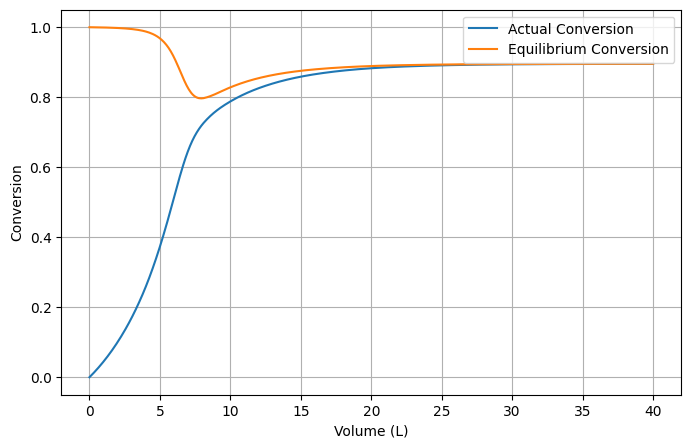

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,X_cocurr,label="Actual Conversion")
plt.plot(V,Xe_cocurr,label="Equilibrium Conversion")
plt.xlabel("Volume (L)")
plt.ylabel("Conversion")
plt.legend()
plt.grid()
plt.show()

#### Plot T and Ta

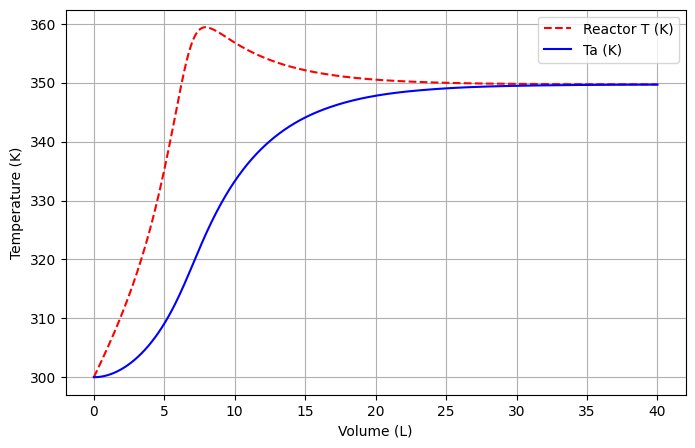

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,T_cocurr,"r--",label="Reactor T (K)")
plt.plot(V,Ta_cocurr,"b-",label="Ta (K)")
plt.xlabel("Volume (L)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid()
plt.show()

#### Plot the Rate

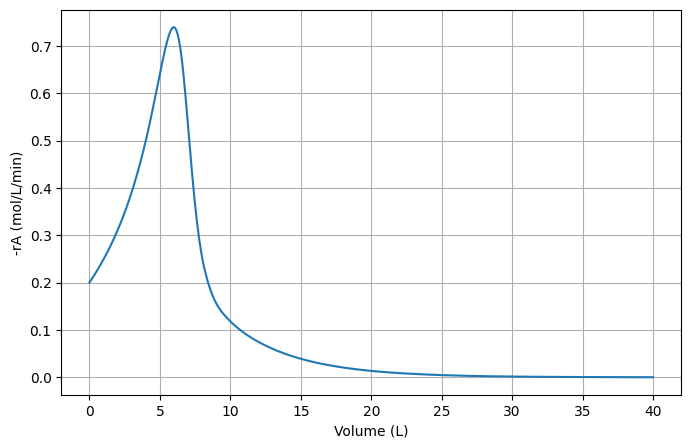

In [ ]:
r_profile_cocurr=-rate(X_cocurr,T_cocurr)
plt.figure(figsize=(8,5))
plt.plot(V,r_profile_cocurr)
plt.xlabel("Volume (L)")
plt.ylabel("-rA (mol/L/min)")
plt.grid()
plt.show()

#### Reactor Exit Conditions

In [ ]:
print("Exit Conversion:",X_cocurr[-1])
print("Exit Temperature (K):",T_cocurr[-1])
print("Exit Equilibrium Conversion:",Xe_cocurr[-1])
print("Fraction of Equilibrium Achieved:",X_cocurr[-1]/Xe_cocurr[-1])

Exit Conversion: 0.8944696613953838
Exit Temperature (K): 349.7145392691061
Exit Equilibrium Conversion: 0.8945581366894355
Fraction of Equilibrium Achieved: 0.9999010960937886


#### Maximum temperature

In [ ]:
print("Maximum Temperature (K):",np.max(T_cocurr))

Maximum Temperature (K): 359.4176784783078


### Variable Ta, counter-current flow

In [ ]:
def countercurrent(V,y):
    X,T,Ta=y
    r=rate(X,T)
    dXdV=-r/FA0
    dTdV=(r*DHrxn+Ua*(Ta-T))/(FA0*CPA)
    dTadV=-Ua*(T-Ta)/(mcool*Cpcool)
    return [dXdV,dTdV,dTadV]

In [ ]:
from scipy.optimize import root_scalar
def objective(Ta0_guess):
  y0 = [x0, T0, Ta0_guess]
  sol =solve_ivp(countercurrent,[0,Vf],y0,method="Radau",t_eval=np.linspace(0,Vf,500))
  Ta_final = sol.y[2, -1]
  return Ta_final - Ta0

In [ ]:
result = root_scalar(objective, bracket=[300, 400], method="brentq")
optimal_Ta0 = result.root

In [ ]:
sol_counter =solve_ivp(countercurrent,[0,Vf],[x0,T0,optimal_Ta0],t_eval=np.linspace(0,Vf,500),method='Radau')
V=sol_counter.t
X_counter=sol_counter.y[0]
T_counter=sol_counter.y[1]
Ta_counter=sol_counter.y[2]
Xe_counter=Xe(T_counter)

#### Plot conversion and equilibrium conversion

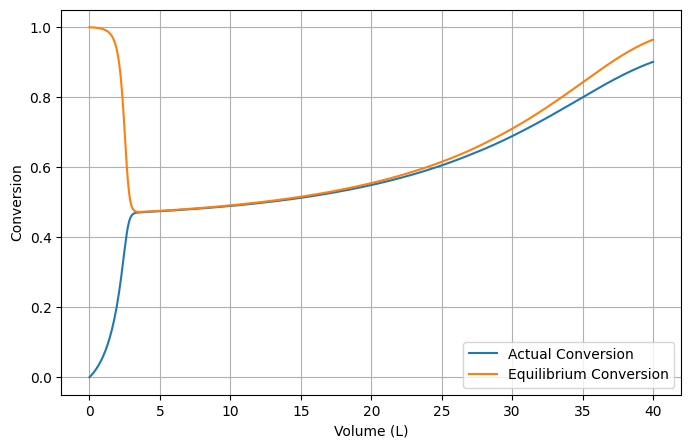

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,X_counter,label="Actual Conversion")
plt.plot(V,Xe_counter,label="Equilibrium Conversion")
plt.xlabel("Volume (L)")
plt.ylabel("Conversion")
plt.legend()
plt.grid()
plt.show()

#### Plot T and Ta

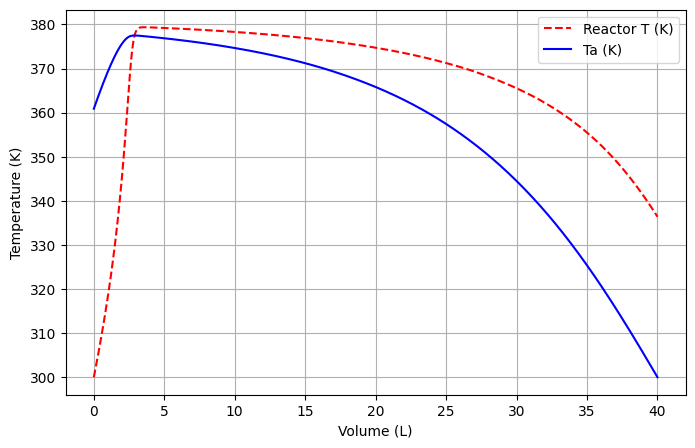

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,T_counter,"r--",label="Reactor T (K)")
plt.plot(V,Ta_counter,"b-",label="Ta (K)")
plt.xlabel("Volume (L)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid()
plt.show()

#### Plot the Rate

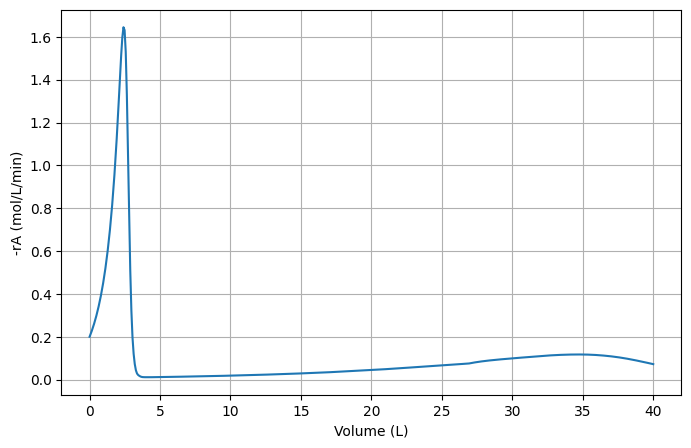

In [ ]:
r_profile_counter=-rate(X_counter,T_counter)
plt.figure(figsize=(8,5))
plt.plot(V,r_profile_counter)
plt.xlabel("Volume (L)")
plt.ylabel("-rA (mol/L/min)")
plt.grid()
plt.show()

#### Reactor Exit Conditions

In [ ]:
print("Exit Conversion:",X_counter[-1])
print("Exit Temperature (K):",T_counter[-1])
print("Exit Equilibrium Conversion:",Xe_counter[-1])
print("Fraction of Equilibrium Achieved:",X_counter[-1]/Xe_counter[-1])

Exit Conversion: 0.9001667877847338
Exit Temperature (K): 336.4012649373048
Exit Equilibrium Conversion: 0.9636392740056796
Fraction of Equilibrium Achieved: 0.9341325245523651


#### Maximum temperature

In [ ]:
print("Maximum Temperature (K):",np.max(T_counter))

Maximum Temperature (K): 379.3777018978191
